In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2

In [2]:
df = pd.read_csv("C:/Users/armin/Downloads/Documents/Datasets/Sign Language/MNIST_SIGN_LANGUAGE/dataset/sign_mnist_train/sign_mnist_train.csv")

In [3]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [4]:
df.describe()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,...,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000
mean,12.318813,145.419377,148.500273,151.247714,153.546531,156.210891,158.411255,160.472154,162.339683,163.954799,...,141.104863,147.495611,153.325806,159.125332,161.969259,162.736696,162.906137,161.966454,161.137898,159.824731
std,7.287552,41.358555,39.942152,39.056286,38.595247,37.111165,36.125579,35.016392,33.661998,32.651607,...,63.751194,65.512894,64.427412,63.708507,63.738316,63.444008,63.509210,63.298721,63.610415,64.396846
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,121.000000,126.000000,130.000000,133.000000,137.000000,140.000000,142.000000,144.000000,146.000000,...,92.000000,96.000000,103.000000,112.000000,120.000000,125.000000,128.000000,128.000000,128.000000,125.500000
50%,13.000000,150.000000,153.000000,156.000000,158.000000,160.000000,162.000000,164.000000,165.000000,166.000000,...,144.000000,162.000000,172.000000,180.000000,183.000000,184.000000,184.000000,182.000000,182.000000,182.000000
75%,19.000000,174.000000,176.000000,178.000000,179.000000,181.000000,182.000000,183.000000,184.000000,185.000000,...,196.000000,202.000000,205.000000,207.000000,208.000000,207.000000,207.000000,206.000000,204.000000,204.000000
max,24.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000


In [5]:
row1 = df.iloc[0]
row1 = row1.to_numpy()[1:].reshape(28, 28)

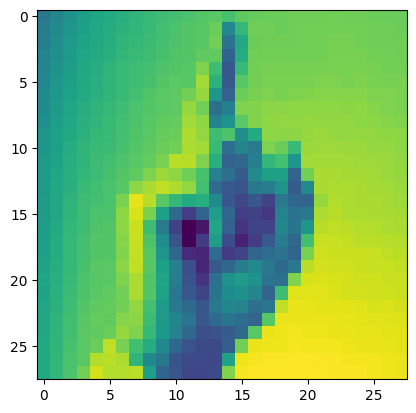

In [6]:
plt.imshow(row1)

In [7]:
df_numpy = df.to_numpy()

In [8]:
df_numpy_labels = df_numpy[:, 0]
df_numpy = df_numpy[:, 1:]

In [9]:
df_numpy_labels

array([ 3,  6,  2, ..., 18, 17, 23], shape=(27455,))

In [10]:
df_numpy = df_numpy / 255
df_numpy = df_numpy.reshape((27455, 28, 28))

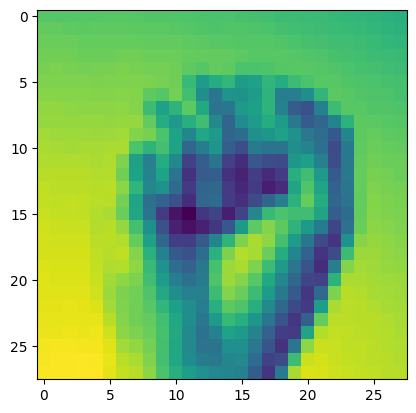

In [11]:
plt.imshow(df_numpy[-3])

In [12]:
df_numpy

array([[[0.41960784, 0.4627451 , 0.49803922, ..., 0.66666667,
         0.66666667, 0.6627451 ],
        [0.43529412, 0.4745098 , 0.50588235, ..., 0.67058824,
         0.67058824, 0.66666667],
        [0.44313725, 0.48235294, 0.51372549, ..., 0.67058824,
         0.67058824, 0.67058824],
        ...,
        [0.55686275, 0.58823529, 0.62352941, ..., 0.79215686,
         0.78823529, 0.78431373],
        [0.55686275, 0.59215686, 0.62745098, ..., 0.8       ,
         0.79607843, 0.79215686],
        [0.55686275, 0.59215686, 0.62745098, ..., 0.8       ,
         0.79607843, 0.79215686]],

       [[0.60784314, 0.61568627, 0.61176471, ..., 0.54117647,
         0.36078431, 0.42352941],
        [0.61960784, 0.62352941, 0.62352941, ..., 0.55686275,
         0.45490196, 0.56078431],
        [0.63137255, 0.63137255, 0.63137255, ..., 0.57647059,
         0.49019608, 0.54901961],
        ...,
        [0.63529412, 0.62352941, 0.56862745, ..., 0.35686275,
         0.39607843, 0.36862745],
        [0.6

(array([3280., 2153., 3307., 1162., 2355., 3402., 2367., 3679., 2243.,
        3507.]),
 array([ 0. ,  2.4,  4.8,  7.2,  9.6, 12. , 14.4, 16.8, 19.2, 21.6, 24. ]),
 <BarContainer object of 10 artists>)

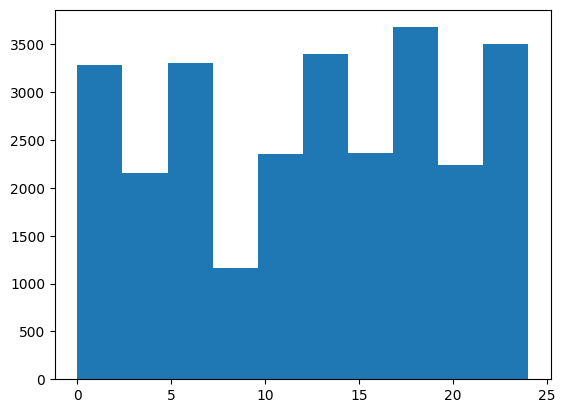

In [13]:
plt.hist(df_numpy_labels)

In [14]:
img_height, img_width = 28, 28
num_classes = 25 
input_shape = (img_height, img_width, 1)

model = Sequential([
    
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape, padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    
    Flatten(),
    
    Dropout(0.5),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),

    Dense(num_classes, activation='softmax') 
])

model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])


model.summary()

print("\nModel defined and compiled successfully!")
print("This architecture includes CNN layers for feature extraction and regularization (Dropout, L2) to combat overfitting.")
print("Remember to load your data, ensure labels match the loss function, and call model.fit() to train it.")


c:\Users\armin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243,481 (951.10 KB)

 Trainable params: 243,481 (951.10 KB)

 Non-trainable params: 0 (0.00 B)


Model defined and compiled successfully!
This architecture includes CNN layers for feature extraction and regularization (Dropout, L2) to combat overfitting.
Remember to load your data, ensure labels match the loss function, and call model.fit() to train it.


In [15]:
x_train = df_numpy.reshape((df_numpy.shape[0], 28, 28, 1))
x_train

array([[[[0.41960784],
         [0.4627451 ],
         [0.49803922],
         ...,
         [0.66666667],
         [0.66666667],
         [0.6627451 ]],

        [[0.43529412],
         [0.4745098 ],
         [0.50588235],
         ...,
         [0.67058824],
         [0.67058824],
         [0.66666667]],

        [[0.44313725],
         [0.48235294],
         [0.51372549],
         ...,
         [0.67058824],
         [0.67058824],
         [0.67058824]],

        ...,

        [[0.55686275],
         [0.58823529],
         [0.62352941],
         ...,
         [0.79215686],
         [0.78823529],
         [0.78431373]],

        [[0.55686275],
         [0.59215686],
         [0.62745098],
         ...,
         [0.8       ],
         [0.79607843],
         [0.79215686]],

        [[0.55686275],
         [0.59215686],
         [0.62745098],
         ...,
         [0.8       ],
         [0.79607843],
         [0.79215686]]],


       [[[0.60784314],
         [0.61568627],
         [0.61

In [16]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(df_numpy_labels, num_classes)

In [17]:
set(df_numpy_labels)

{np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24)}

In [18]:
model.fit(x_train, y_train, epochs=30)

Epoch 1/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.5007 - loss: 1.6920
Epoch 2/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8708 - loss: 0.5216
Epoch 3/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9269 - loss: 0.3712
Epoch 4/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9488 - loss: 0.3022
Epoch 5/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9590 - loss: 0.2674
Epoch 6/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9655 - loss: 0.2399
Epoch 7/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9719 - loss: 0.2166
Epoch 8/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9753 - loss: 0.2017
Epoch 9/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9756 - loss: 0.1971
Epoch 10/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9792 - loss: 0.1839
Epoch 11/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9801 - loss: 0.1768
Epoch 12/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 8

In [19]:
df_test = pd.read_csv("C:/Users/armin/Downloads/Documents/Datasets/Sign Language/MNIST_SIGN_LANGUAGE/dataset/sign_mnist_test/sign_mnist_test.csv")

In [20]:
df_numpy_test = df_test.to_numpy()

In [21]:
df_numpy_test_labels = df_numpy_test[:, 0]
df_numpy_test = df_numpy_test[:, 1:]

In [22]:
df_numpy_test = df_numpy_test / 255
df_numpy_test = df_numpy_test.reshape((df_numpy_test.shape[0], 28, 28))

In [23]:
x_test = df_numpy_test.reshape((df_numpy_test.shape[0], 28, 28, 1))
y_test = to_categorical(df_numpy_test_labels, num_classes)

In [24]:
model.evaluate(x_test, y_test, verbose=1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9842 - loss: 0.1394


[0.1394393891096115, 0.9842442870140076]

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Actual label:     7
Predicted label:  7
Confidence:       0.9999728


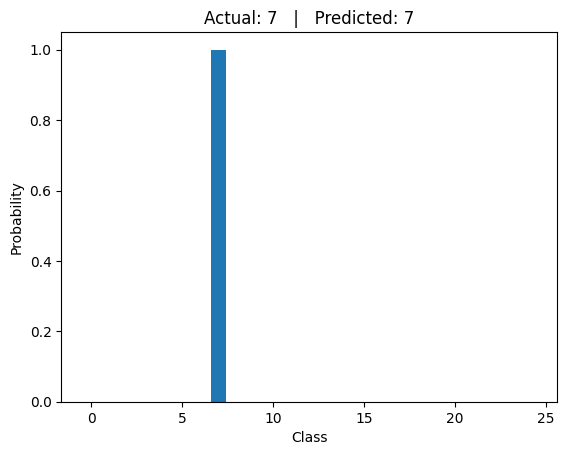

In [43]:
i = 30 #test index
pred = model.predict(df_numpy_test)[i]
predicted_label = pred.argmax()
print("Actual label:    ", df_test["label"][i])
print("Predicted label: ", predicted_label)
print("Confidence:      ", pred[predicted_label])

plt.bar(range(25), pred)
plt.xlabel("Class")
plt.ylabel("Probability")
plt.title(f"Actual: {df_test["label"][i]}   |   Predicted: {predicted_label}")
plt.show()
